In [4]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import date


# ============================================================
# Files
# ============================================================

BASE_LIM_DIR = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS"
)

# Use exactly the same regional state vectors as the LIM skill calculation.
# valid_zero30:
#   grid cells with more than 30% zero/missing values were excluded
#   -> retained cells have at least 70% valid PP data.
LIM_FILE = BASE_LIM_DIR / (
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
    "PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)

# If the sensitivity LIM used PP_valid_only, use this instead:
# LIM_FILE = BASE_LIM_DIR / (
#     "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
#     "PP_valid_only_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
# )

OUT_DIR = BASE_LIM_DIR / "skill"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FILE = OUT_DIR / (
    "Persistence_PP_forecast_skill_24month_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

MAX_LEAD = 24
THRESHOLD = 0.5
TARGET_STATE = "PP"


# ============================================================
# Helper functions
# ============================================================

def decode_str_array(values):
    """
    Convert netCDF string or byte-string arrays to Python strings.
    """
    out = []

    for value in values:
        if isinstance(value, bytes):
            out.append(value.decode("utf-8"))
        else:
            out.append(str(value))

    return np.array(out, dtype=object)


def corr_1d(a, b):
    """
    Pearson correlation with NaN handling.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)

    if ok.sum() < 3:
        return np.nan

    aa = a[ok]
    bb = b[ok]

    if np.nanstd(aa) == 0 or np.nanstd(bb) == 0:
        return np.nan

    return np.corrcoef(aa, bb)[0, 1]


def latest_skill_month(skill, threshold=0.5):
    """
    Return the latest lead month with correlation >= threshold.

    The input skill dimension represents lead months 1..MAX_LEAD.
    Zero means that no lead month satisfies the threshold.
    """
    good = np.where(
        np.isfinite(skill) & (skill >= threshold)
    )[0]

    if len(good) == 0:
        return 0

    return int(good.max() + 1)


def get_region_var(
    ds,
    name,
    regions,
    dtype=None,
    fill_value=None,
):
    """
    Safely extract a region metadata variable.
    """
    n_region = len(regions)

    if name not in ds:
        return np.full(n_region, fill_value)

    arr = ds[name].sel(region=regions).values

    if dtype is not None:
        arr = arr.astype(dtype)

    return arr


# ============================================================
# Load state vector
# ============================================================

ds_lim = xr.open_dataset(LIM_FILE)

if "state_vector" not in ds_lim:
    raise KeyError(f"state_vector not found in {LIM_FILE}")

state_vector = ds_lim["state_vector"].transpose(
    "region",
    "time",
    "state",
)

# All regions already retained in the valid-zero30 LIM file are used.
regions = state_vector["region"].values.astype(np.int16)
times = state_vector["time"].values
states = state_vector["state"].values.astype(str)

if TARGET_STATE not in states:
    raise ValueError(
        f"{TARGET_STATE} not found in state dimension: {list(states)}"
    )

months = pd.to_datetime(times).month.values.astype(np.int16)

n_region = len(regions)
n_time = len(times)

lead_coord = np.arange(
    1,
    MAX_LEAD + 1,
    dtype=np.int16,
)

print("LIM file:", LIM_FILE)
print("n_region:", n_region)
print("n_time:", n_time)
print("states:", list(states))
print("regions:", regions)


# ============================================================
# Persistence forecast and skill
# ============================================================

# Persistence prediction:
# PP_hat(t + lead) = PP(t)
pp_pred = np.full(
    (n_region, n_time, MAX_LEAD),
    np.nan,
    dtype=np.float32,
)

# Pooled skill across all initialization months
pp_corr = np.full(
    (n_region, MAX_LEAD),
    np.nan,
    dtype=np.float64,
)

n_pairs = np.zeros(
    (n_region, MAX_LEAD),
    dtype=np.int16,
)

# Skill separated by initialization calendar month
pp_corr_by_init_month = np.full(
    (n_region, 12, MAX_LEAD),
    np.nan,
    dtype=np.float64,
)

n_pairs_by_init_month = np.zeros(
    (n_region, 12, MAX_LEAD),
    dtype=np.int16,
)


for ir, reg in enumerate(regions):

    print(
        f"[{ir + 1:02d}/{n_region:02d}] "
        f"persistence skill for region {int(reg)}"
    )

    pp = (
        state_vector
        .sel(region=reg, state=TARGET_STATE)
        .values
        .astype(np.float64)
    )

    for lead in range(1, MAX_LEAD + 1):

        # Initial times for which t + lead exists
        init_idx = np.arange(
            0,
            n_time - lead,
        )

        # Persistence prediction
        pred = pp[init_idx]
        obs = pp[init_idx + lead]

        pp_pred[
            ir,
            init_idx,
            lead - 1,
        ] = pred.astype(np.float32)

        ok = np.isfinite(pred) & np.isfinite(obs)

        n_pairs[ir, lead - 1] = ok.sum()

        pp_corr[ir, lead - 1] = corr_1d(
            pred,
            obs,
        )

        # ----------------------------------------------------
        # Skill by initialization calendar month
        # ----------------------------------------------------
        for month in range(1, 13):

            idx_month = init_idx[
                months[init_idx] == month
            ]

            pred_month = pp[idx_month]
            obs_month = pp[idx_month + lead]

            ok_month = (
                np.isfinite(pred_month)
                & np.isfinite(obs_month)
            )

            n_pairs_by_init_month[
                ir,
                month - 1,
                lead - 1,
            ] = ok_month.sum()

            pp_corr_by_init_month[
                ir,
                month - 1,
                lead - 1,
            ] = corr_1d(
                pred_month,
                obs_month,
            )


# ============================================================
# Latest lead with correlation >= threshold
# ============================================================

latest_lead = np.zeros(
    n_region,
    dtype=np.int16,
)

latest_lead_by_init_month = np.zeros(
    (n_region, 12),
    dtype=np.int16,
)

for ir in range(n_region):

    latest_lead[ir] = latest_skill_month(
        pp_corr[ir, :],
        threshold=THRESHOLD,
    )

    for month_index in range(12):

        latest_lead_by_init_month[
            ir,
            month_index,
        ] = latest_skill_month(
            pp_corr_by_init_month[
                ir,
                month_index,
                :,
            ],
            threshold=THRESHOLD,
        )


# ============================================================
# Region metadata from LIM file
# ============================================================

if "region_name" in ds_lim:
    region_name_values = decode_str_array(
        ds_lim["region_name"]
        .sel(region=regions)
        .values
    )
else:
    region_name_values = np.array(
        [f"region {int(region)}" for region in regions],
        dtype=object,
    )


if "basin" in ds_lim:
    basin_values = decode_str_array(
        ds_lim["basin"]
        .sel(region=regions)
        .values
    )
else:
    basin_values = np.array(
        [""] * n_region,
        dtype=object,
    )


original_region_id_values = get_region_var(
    ds_lim,
    "original_region_id",
    regions,
    dtype=np.int16,
    fill_value=-999,
)

n_total_cells_original_mask = get_region_var(
    ds_lim,
    "n_total_cells_original_mask",
    regions,
    dtype=np.int32,
    fill_value=-999,
)

n_valid_cells_threshold_mask = get_region_var(
    ds_lim,
    "n_valid_cells_threshold_mask",
    regions,
    dtype=np.int32,
    fill_value=-999,
)

valid_fraction_percent_threshold_mask = get_region_var(
    ds_lim,
    "valid_fraction_percent_threshold_mask",
    regions,
    dtype=np.float32,
    fill_value=np.nan,
)

n_cells_used_for_regional_mean = get_region_var(
    ds_lim,
    "n_cells_used_for_regional_mean",
    regions,
    dtype=np.int32,
    fill_value=-999,
)

area_weight_used_for_regional_mean = get_region_var(
    ds_lim,
    "area_weight_used_for_regional_mean",
    regions,
    dtype=np.float64,
    fill_value=np.nan,
)


# ============================================================
# Save skill output
# ============================================================

ds_skill_persistence = xr.Dataset(
    data_vars={

        "PP_prediction_persistence": (
            ("region", "init_time", "lead"),
            pp_pred,
            {
                "long_name": (
                    "Persistence predicted standardized PP anomaly"
                ),
                "description": (
                    "Persistence forecast: "
                    "PP_hat(t + lead) = PP(t)."
                ),
                "units": "standard deviation",
            },
        ),

        "PP_correlation_skill_persistence": (
            ("region", "lead"),
            pp_corr.astype(np.float32),
            {
                "long_name": (
                    "Persistence PP forecast correlation skill"
                ),
                "description": (
                    "Correlation between persistence-predicted "
                    "and observed standardized PP anomalies, "
                    "pooled across all initialization months."
                ),
                "threshold_reference": THRESHOLD,
            },
        ),

        "PP_correlation_skill_persistence_by_init_month": (
            ("region", "init_month", "lead"),
            pp_corr_by_init_month.astype(np.float32),
            {
                "long_name": (
                    "Persistence PP forecast correlation skill "
                    "by initialization month"
                ),
                "description": (
                    "Correlation between persistence-predicted "
                    "and observed PP anomalies, calculated "
                    "separately for each initialization month."
                ),
                "threshold_reference": THRESHOLD,
            },
        ),

        "n_pairs": (
            ("region", "lead"),
            n_pairs,
            {
                "long_name": (
                    "Number of persistence forecast-observation pairs"
                ),
            },
        ),

        "n_pairs_by_init_month": (
            ("region", "init_month", "lead"),
            n_pairs_by_init_month,
            {
                "long_name": (
                    "Number of persistence forecast-observation "
                    "pairs by initialization month"
                ),
            },
        ),

        "latest_lead_corr_ge_05_persistence": (
            ("region",),
            latest_lead,
            {
                "long_name": (
                    "Latest lead month with persistence PP "
                    "correlation skill >= 0.5"
                ),
                "units": "month",
                "description": (
                    "Pooled across all initialization months. "
                    "Zero means no lead month has correlation "
                    "skill >= 0.5."
                ),
            },
        ),

        "latest_lead_corr_ge_05_persistence_by_init_month": (
            ("region", "init_month"),
            latest_lead_by_init_month,
            {
                "long_name": (
                    "Latest lead month with persistence PP "
                    "correlation skill >= 0.5 by initialization month"
                ),
                "units": "month",
                "description": (
                    "Calculated separately for each initialization "
                    "calendar month. Zero means no lead month has "
                    "correlation skill >= 0.5."
                ),
            },
        ),

        "region_name": (
            ("region",),
            region_name_values.astype(object),
            {
                "long_name": "RECCAP2 region name",
            },
        ),

        "basin": (
            ("region",),
            basin_values.astype(object),
            {
                "long_name": "Original RECCAP2 basin",
            },
        ),

        "original_region_id": (
            ("region",),
            original_region_id_values.astype(np.int16),
            {
                "long_name": "Original RECCAP2 region ID",
            },
        ),

        "n_total_cells_original_mask": (
            ("region",),
            n_total_cells_original_mask.astype(np.int32),
            {
                "long_name": (
                    "Number of grid cells in the original "
                    "RECCAP2 region mask"
                ),
            },
        ),

        "n_valid_cells_threshold_mask": (
            ("region",),
            n_valid_cells_threshold_mask.astype(np.int32),
            {
                "long_name": (
                    "Number of grid cells retained after applying "
                    "the 70-percent-valid-data threshold"
                ),
            },
        ),

        "valid_fraction_percent_threshold_mask": (
            ("region",),
            valid_fraction_percent_threshold_mask.astype(np.float32),
            {
                "long_name": (
                    "Fraction of original regional grid cells retained "
                    "after the valid-data threshold"
                ),
                "units": "%",
            },
        ),

        "n_cells_used_for_regional_mean": (
            ("region",),
            n_cells_used_for_regional_mean.astype(np.int32),
            {
                "long_name": (
                    "Number of retained grid cells used for "
                    "the PP regional mean"
                ),
            },
        ),

        "area_weight_used_for_regional_mean": (
            ("region",),
            area_weight_used_for_regional_mean.astype(np.float64),
            {
                "long_name": (
                    "Latitude-weighted area denominator used "
                    "for the PP regional mean"
                ),
            },
        ),
    },

    coords={
        "region": regions,
        "init_time": times,
        "lead": lead_coord,
        "init_month": np.arange(
            1,
            13,
            dtype=np.int16,
        ),
    },

    attrs={
        "title": (
            "Persistence PP forecast skill over valid-zero30 "
            "RECCAP2 all-region mask"
        ),
        "description": (
            "Persistence forecast skill for regional standardized "
            "PP anomalies using the same regional state vectors as "
            "the all-regions valid-zero30 cyclostationary LIM."
        ),
        "lim_file_used_for_state_vector": str(LIM_FILE),
        "target_state": TARGET_STATE,
        "max_lead_months": MAX_LEAD,
        "correlation_threshold": THRESHOLD,
        "method": (
            "For every retained RECCAP2 region and monthly "
            "initialization, PP was forecast for lead months 1-24 "
            "using PP_hat(t+lead)=PP(t). Pearson correlation was "
            "calculated between predicted and observed standardized "
            "PP anomalies."
        ),
        "region_mask_note": (
            "The regional state vectors were taken directly from the "
            "valid-zero30 all-region LIM file. Grid cells with more "
            "than 30 percent zero or unavailable PP values were "
            "excluded, so retained grid cells contain at least "
            "70 percent valid PP data."
        ),
        "created_by": "custom Python/xarray script",
        "date_created": date.today().isoformat(),
    },
)


# ============================================================
# Encoding and save
# ============================================================

encoding = {
    "PP_prediction_persistence": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },

    "PP_correlation_skill_persistence": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },

    "PP_correlation_skill_persistence_by_init_month": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },

    "n_pairs": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "n_pairs_by_init_month": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "latest_lead_corr_ge_05_persistence": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "latest_lead_corr_ge_05_persistence_by_init_month": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "original_region_id": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "n_total_cells_original_mask": {
        "dtype": "int32",
        "_FillValue": None,
    },

    "n_valid_cells_threshold_mask": {
        "dtype": "int32",
        "_FillValue": None,
    },

    "valid_fraction_percent_threshold_mask": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
    },

    "n_cells_used_for_regional_mean": {
        "dtype": "int32",
        "_FillValue": None,
    },

    "area_weight_used_for_regional_mean": {
        "dtype": "float64",
        "_FillValue": None,
    },

    "region": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "lead": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "init_month": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "init_time": {
        "dtype": "float64",
        "units": "days since 1900-01-01",
        "calendar": "gregorian",
    },
}


if OUT_FILE.exists():
    OUT_FILE.unlink()

ds_skill_persistence.to_netcdf(
    OUT_FILE,
    encoding=encoding,
    engine="netcdf4",
)

print(f"\nSaved: {OUT_FILE}")
print(ds_skill_persistence)

LIM file: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc
n_region: 21
n_time: 336
states: ['PP', 'TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
[01/21] persistence skill for region 1
[02/21] persistence skill for region 2
[03/21] persistence skill for region 3
[04/21] persistence skill for region 4
[05/21] persistence skill for region 5
[06/21] persistence skill for region 6
[07/21] persistence skill for region 7
[08/21] persistence skill for region 8
[09/21] persistence skill for region 9
[10/21] persistence skill for region 10
[11/21] persistence skill for region 11
[12/21] persistence skill for region 12
[13/21] persistence skill for region 13
[14/21] persistence skill for region 14
[15/21] persistence skill for region 15
[16/21] persistence skill for region 16
[17/21] persistence skil

Original mask regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
Plot mask regions: [ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 27 28]
Original persistence skill regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
Plotted persistence skill regions: [ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 27 28]


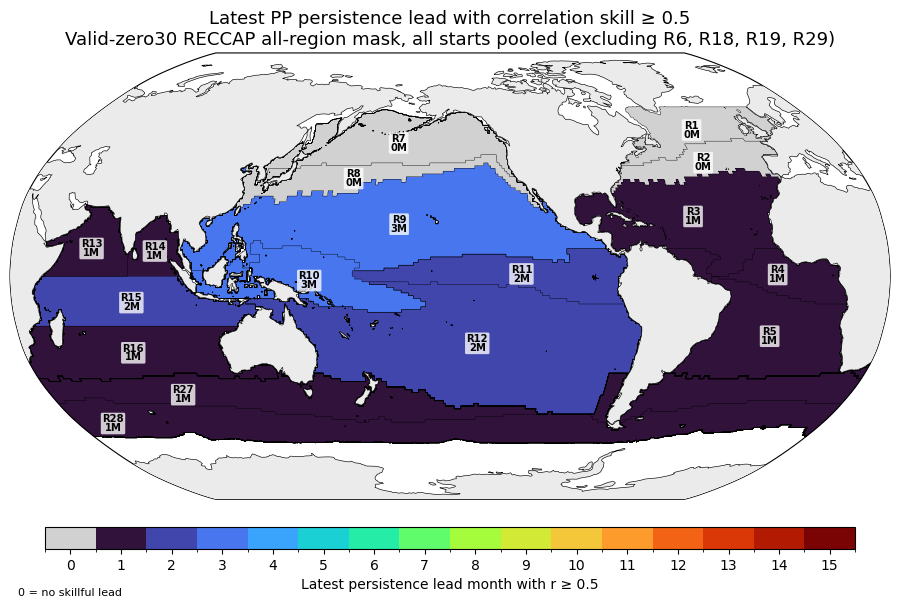

In [5]:
# ============================================================
# Map latest persistence skillful lead by valid-zero30 region
# excluding selected regions only for plotting
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path


# ============================================================
# Files
# ============================================================

VALID_MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "GlobColour_PP_grid_validity_RECCAP2_all_regions/"
    "valid_mask_zero30/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)

SKILL_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/"
    "Persistence_PP_forecast_skill_24month_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

MAX_LEAD = 24
THRESHOLD = 0.5

CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4

# Regions excluded only from this figure
EXCLUDE_PLOT_REGIONS = [6, 18, 19, 29]

DISPLAY_MAX_LEAD = 15

OUT_FIG = SKILL_FILE.parent / (
    "Map_latest_PP_persistence_skillful_lead_corr_ge_05_"
    "RECCAP2_all_regions_valid_zero30_excluding_R6_R18_R19_R29.png"
)


# ============================================================
# Helper functions
# ============================================================

def lon_to_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, mask):
    """
    Area-weighted centroid using cosine latitude weights.
    Longitude centroid is circular.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    wsum = np.nansum(weights)

    if wsum <= 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)

    x = np.nansum(weights * np.cos(lon_rad)) / wsum
    y = np.nansum(weights * np.sin(lon_rad)) / wsum

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / wsum

    return lon_c, lat_c


def add_cyclic_manual(data, lon):
    """
    Add cyclic longitude column without requiring perfectly equal spacing.
    """
    lon = np.asarray(lon, dtype=np.float64)

    sort_idx = np.argsort(lon)
    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]

    dlon = float(np.nanmedian(np.diff(lon_sorted)))

    lon_cyc = np.concatenate(
        [lon_sorted, [lon_sorted[-1] + dlon]]
    )

    data_cyc = np.concatenate(
        [data_sorted, data_sorted[:, :1]],
        axis=1,
    )

    return data_cyc, lon_cyc


# ============================================================
# Load mask and persistence skill
# ============================================================

ds_mask = xr.open_dataset(VALID_MASK_FILE)
ds_skill = xr.open_dataset(SKILL_FILE)

mask = ds_mask["valid_region_mask"]

latest = ds_skill[
    "latest_lead_corr_ge_05_persistence"
]

lat = ds_mask["latitude"].values.astype(float)
lon = ds_mask["longitude"].values.astype(float)

mask_values = mask.values.astype(np.int16)


# ============================================================
# Exclude selected regions only for plotting
# ============================================================

mask_plot_full = mask_values.copy()

for reg_ex in EXCLUDE_PLOT_REGIONS:
    mask_plot_full[mask_plot_full == reg_ex] = 0


regions_to_plot = [
    int(reg)
    for reg in latest["region"].values
    if int(reg) not in EXCLUDE_PLOT_REGIONS
]

latest_plot = latest.sel(region=regions_to_plot)


print(
    "Original mask regions:",
    np.unique(mask_values[mask_values > 0]),
)

print(
    "Plot mask regions:",
    np.unique(mask_plot_full[mask_plot_full > 0]),
)

print(
    "Original persistence skill regions:",
    latest["region"].values,
)

print(
    "Plotted persistence skill regions:",
    latest_plot["region"].values,
)


# ============================================================
# Build lead map on PP grid
# ============================================================

lead_map = np.full(
    mask_values.shape,
    np.nan,
    dtype=np.float32,
)

for reg in latest_plot["region"].values:

    reg = int(reg)

    val = float(
        latest_plot.sel(region=reg).values
    )

    lead_map[mask_plot_full == reg] = val


# Outside retained and plotted regions -> NaN
lead_map = np.where(
    mask_plot_full > 0,
    lead_map,
    np.nan,
)


# ============================================================
# Coarsen for plotting only
# ============================================================

lat_plot = lat[::PLOT_STRIDE]
lon_plot = lon[::PLOT_STRIDE]

lead_plot = lead_map[
    ::PLOT_STRIDE,
    ::PLOT_STRIDE,
]

mask_plot = mask_plot_full[
    ::PLOT_STRIDE,
    ::PLOT_STRIDE,
].astype(float)


lead_cyc, lon_cyc = add_cyclic_manual(
    lead_plot,
    lon_plot,
)

mask_cyc, _ = add_cyclic_manual(
    mask_plot,
    lon_plot,
)


# Boundary levels based on remaining plotted regions
remaining_regions = np.unique(
    mask_plot_full[mask_plot_full > 0]
)

boundary_levels = np.arange(
    0.5,
    int(np.nanmax(remaining_regions)) + 1.5,
    1.0,
)


# ============================================================
# Discrete color scale
# ============================================================

lead_cyc_plot = lead_cyc.copy()

lead_cyc_plot = np.where(
    np.isfinite(lead_cyc_plot),
    np.minimum(
        lead_cyc_plot,
        DISPLAY_MAX_LEAD,
    ),
    np.nan,
)


bounds = np.arange(
    -0.5,
    DISPLAY_MAX_LEAD + 1.5,
    1.0,
)


try:
    base = plt.get_cmap(
        "turbo",
        DISPLAY_MAX_LEAD,
    )

except ValueError:
    base = plt.get_cmap(
        "plasma",
        DISPLAY_MAX_LEAD,
    )


colors = (
    [(0.82, 0.82, 0.82, 1.0)]
    + [
        base(i)
        for i in range(DISPLAY_MAX_LEAD)
    ]
)

cmap = ListedColormap(colors)
cmap.set_bad((1, 1, 1, 0))

norm = BoundaryNorm(
    bounds,
    cmap.N,
)


# ============================================================
# Plot
# ============================================================

fig = plt.figure(
    figsize=(13.5, 6.2)
)

ax = plt.axes(
    projection=ccrs.Robinson(
        central_longitude=CENTRAL_LONGITUDE
    )
)


im = ax.pcolormesh(
    lon_cyc,
    lat_plot,
    lead_cyc_plot,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree(),
)


# Valid-zero30 region boundaries after exclusion
ax.contour(
    lon_cyc,
    lat_plot,
    mask_cyc,
    levels=boundary_levels,
    colors="k",
    linewidths=0.30,
    transform=ccrs.PlateCarree(),
)


ax.add_feature(
    cfeature.LAND,
    facecolor="0.92",
    edgecolor="none",
    zorder=3,
)

ax.coastlines(
    linewidth=0.45,
    zorder=4,
)

ax.set_global()


ax.set_title(
    "Latest PP persistence lead with correlation skill ≥ 0.5\n"
    "Valid-zero30 RECCAP all-region mask, "
    "all starts pooled (excluding R6, R18, R19, R29)",
    fontsize=13,
)


# ============================================================
# Region labels
# ============================================================

for reg in latest_plot["region"].values:

    reg = int(reg)

    region_mask = mask_plot_full == reg

    if not np.any(region_mask):
        continue

    lon_c, lat_c = weighted_centroid(
        lon,
        lat,
        region_mask,
    )

    if np.isfinite(lon_c) and np.isfinite(lat_c):

        val = float(
            latest_plot.sel(region=reg).values
        )

        if not np.isfinite(val):
            continue

        label_text = f"R{reg}\n{int(val)}M"

        ax.text(
            lon_to_180(lon_c),
            lat_c,
            label_text,
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=7.2,
            fontweight="bold",
            linespacing=0.85,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.78,
                boxstyle="round,pad=0.14",
            ),
            zorder=5,
        )


# ============================================================
# Colorbar
# ============================================================

fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.88,
    bottom=0.16,
)

cax = fig.add_axes(
    [0.20, 0.08, 0.60, 0.035]
)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(
        0,
        DISPLAY_MAX_LEAD + 1,
        1,
    ),
    boundaries=bounds,
)

cbar.set_label(
    "Latest persistence lead month with r ≥ 0.5"
)

cbar.ax.text(
    0,
    -1.8,
    "0 = no skillful lead",
    ha="center",
    va="top",
    transform=cbar.ax.get_xaxis_transform(),
    fontsize=8,
)


plt.show()

# plt.savefig(
#     OUT_FIG,
#     dpi=200,
#     bbox_inches="tight",
# )
#
# print(f"Saved figure: {OUT_FIG}")

<xarray.Dataset>
Dimensions:                                           (region: 21,
                                                       init_time: 336,
                                                       lead: 24, init_month: 12)
Coordinates:
  * region                                            (region) int16 1 2 ... 29
  * init_time                                         (init_time) datetime64[ns] ...
  * lead                                              (lead) int16 1 2 ... 23 24
  * init_month                                        (init_month) int16 1 .....
Data variables: (12/15)
    PP_prediction_persistence                         (region, init_time, lead) float32 ...
    PP_correlation_skill_persistence                  (region, lead) float32 ...
    PP_correlation_skill_persistence_by_init_month    (region, init_month, lead) float32 ...
    n_pairs                                           (region, lead) int16 ...
    n_pairs_by_init_month                             (

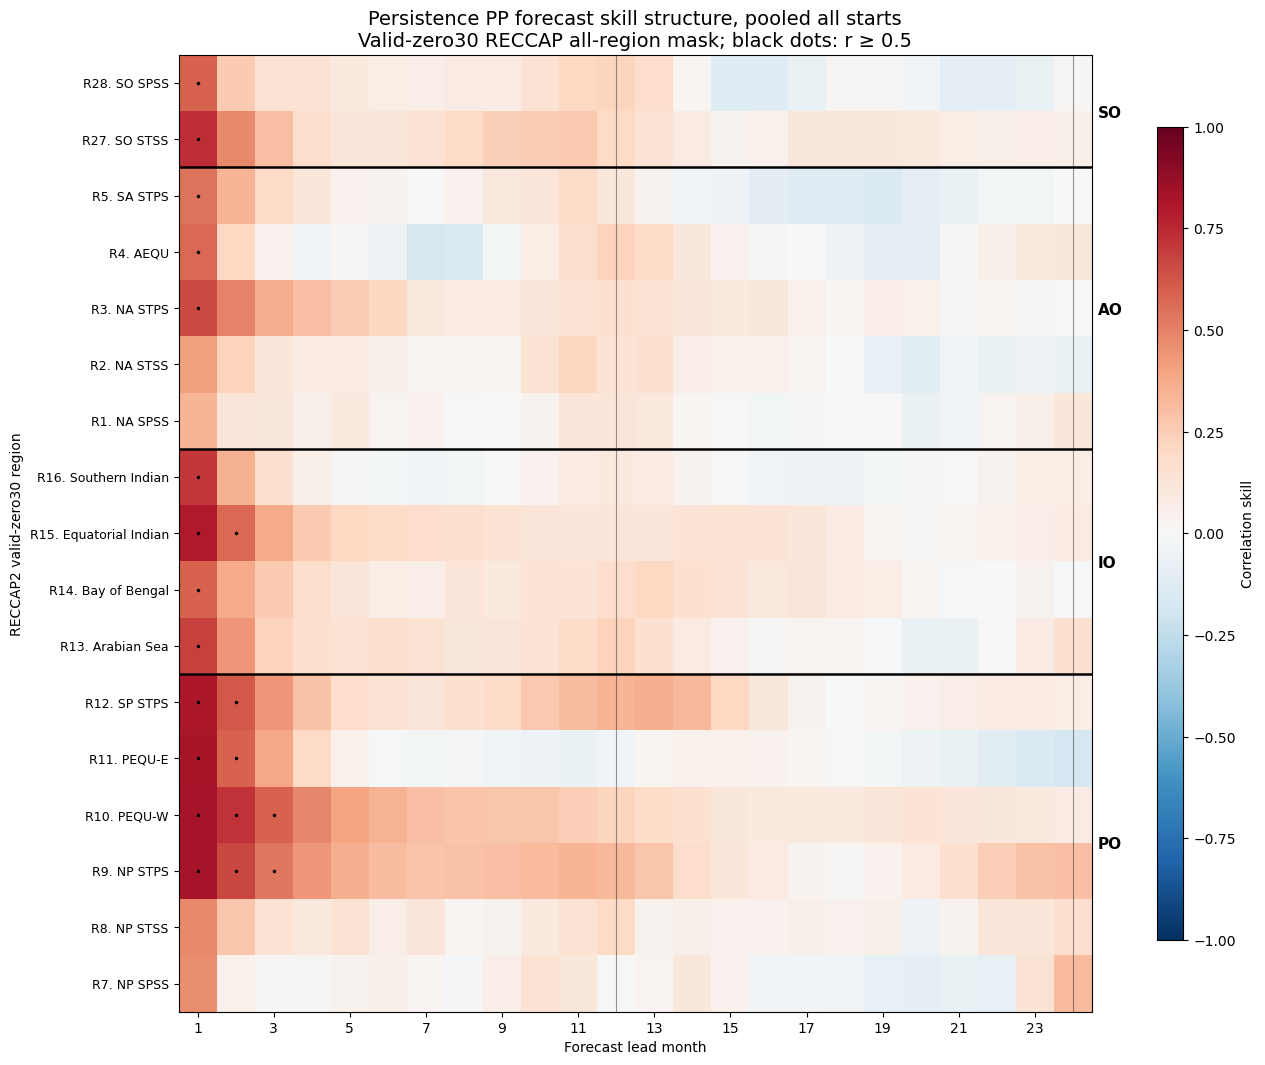

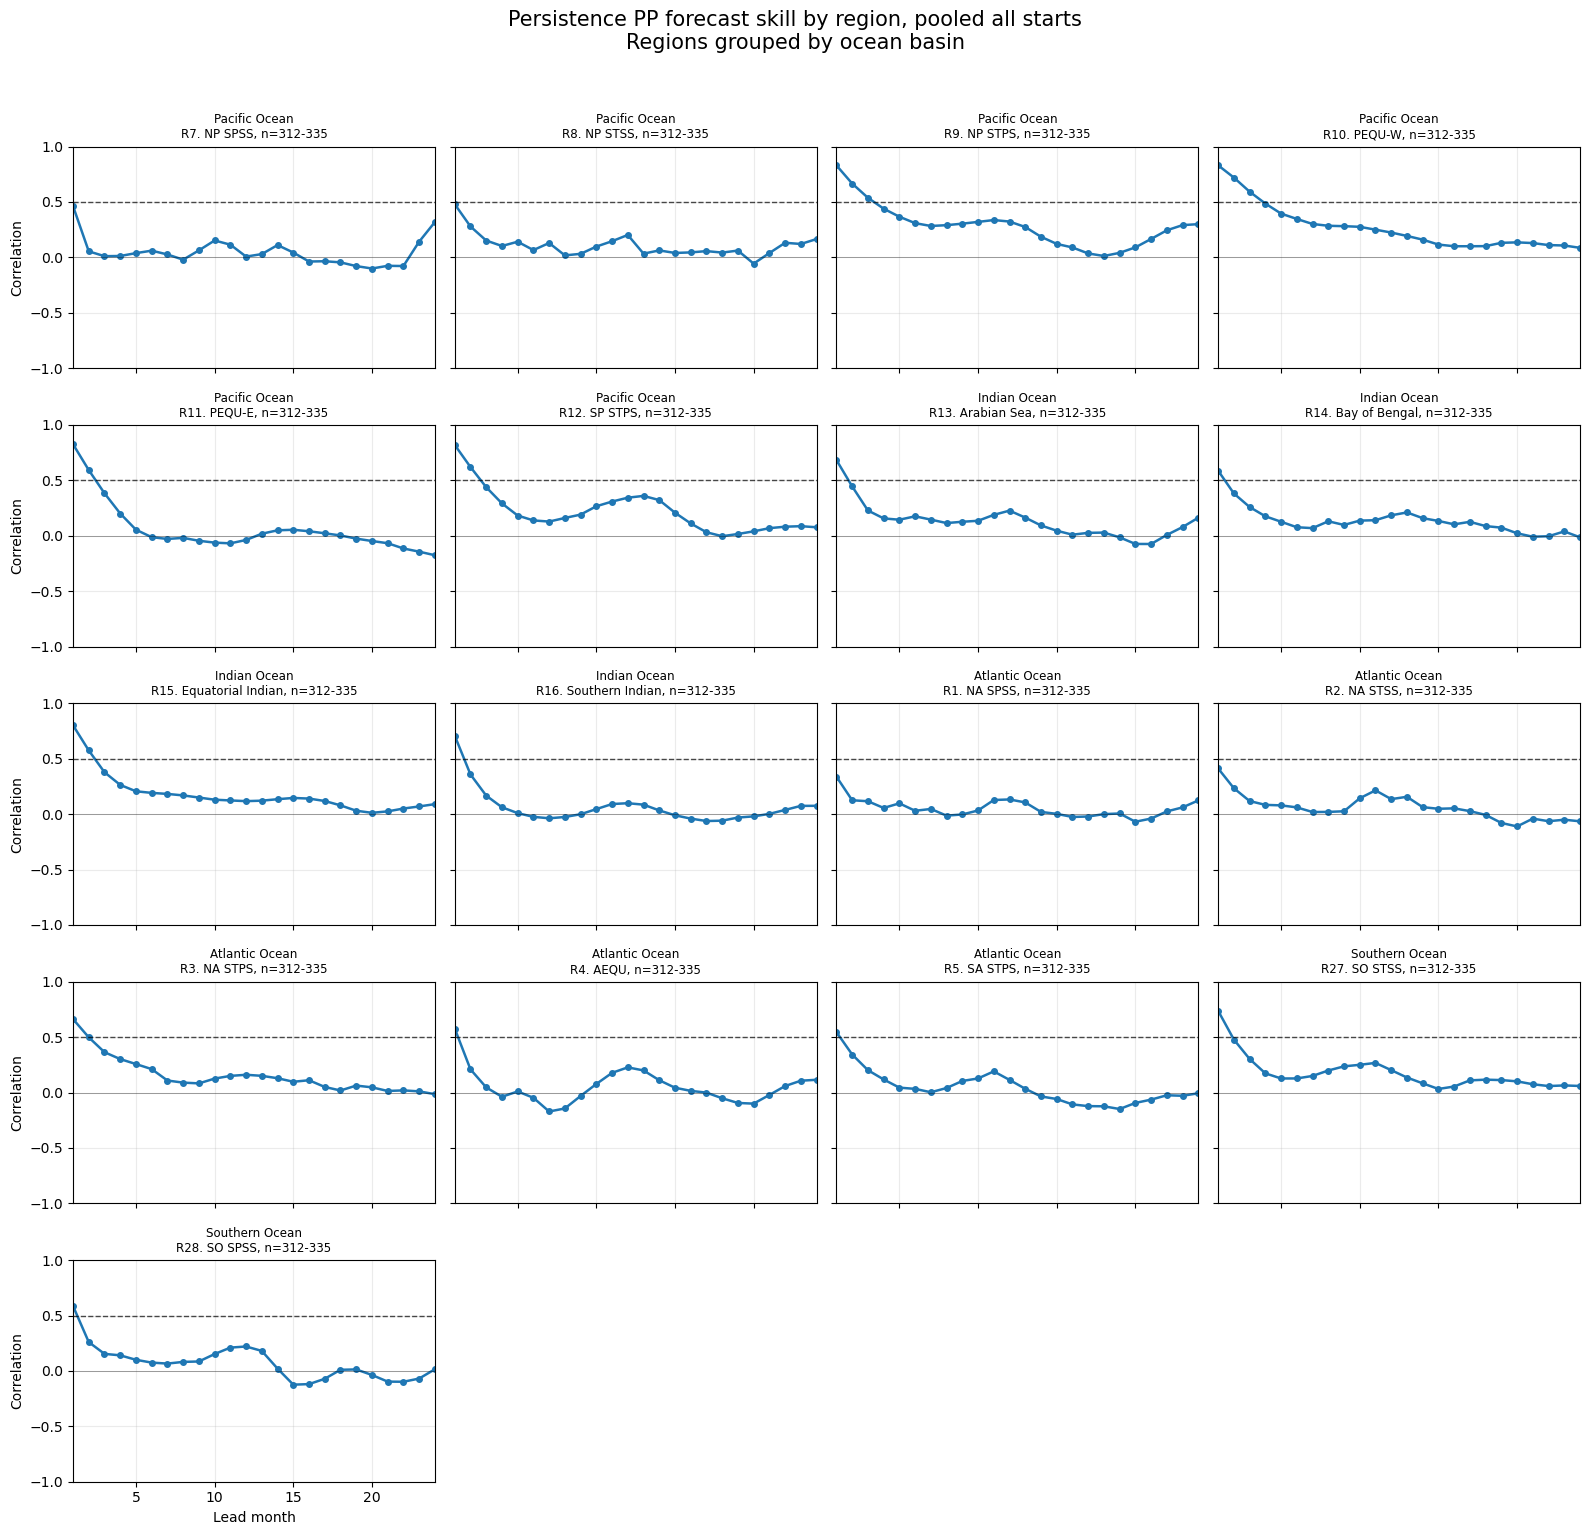

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Settings
# ============================================================

SKILL_FILE = (
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/"
    "Persistence_PP_forecast_skill_24month_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

OUT_DIR = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD = 0.5

FIG_HEATMAP = OUT_DIR / (
    "Persistence_PP_skill_structure_pooled_all_starts_"
    "valid_zero30_allregions_heatmap.png"
)

FIG_LINES = OUT_DIR / (
    "Persistence_PP_skill_structure_pooled_all_starts_"
    "valid_zero30_allregions_regional_lines.png"
)

BASIN_SHORT = {
    "Pacific Ocean": "PO",
    "Indian Ocean": "IO",
    "Atlantic Ocean": "AO",
    "Southern Ocean": "SO",
    "Arctic Ocean": "ArO",
}


# ============================================================
# Helper functions
# ============================================================

def latest_any_1d(r, threshold=0.5):
    """
    Latest lead where r >= threshold anywhere.
    Can be affected by isolated late-lead spikes.
    """
    r = np.asarray(r, dtype=float)
    good = np.where(np.isfinite(r) & (r >= threshold))[0]

    if len(good) == 0:
        return 0

    return int(good.max() + 1)


def latest_contiguous_1d(r, threshold=0.5):
    """
    Latest lead up to which r remains continuously >= threshold
    from lead 1 onward.
    """
    r = np.asarray(r, dtype=float)
    good = np.isfinite(r) & (r >= threshold)

    if len(good) == 0:
        return 0

    if not good[0]:
        return 0

    bad = np.where(~good)[0]

    if len(bad) == 0:
        return int(len(good))

    return int(bad[0])


def decode_str(v):
    """
    Decode netCDF string / byte-string scalar.
    """
    if isinstance(v, bytes):
        return v.decode("utf-8")

    arr = np.asarray(v)

    if arr.shape == ():
        item = arr.item()

        if isinstance(item, bytes):
            return item.decode("utf-8")

        return str(item)

    return str(v)


def get_region_label(ds, reg, short=True):
    """
    Region label for plotting.
    """
    reg = int(reg)

    if "region_name" in ds:
        try:
            name = decode_str(
                ds["region_name"].sel(region=reg).values
            )
        except Exception:
            name = f"region {reg}"
    else:
        name = f"region {reg}"

    if "basin" in ds:
        try:
            basin = decode_str(
                ds["basin"].sel(region=reg).values
            )
        except Exception:
            basin = ""
    else:
        basin = ""

    if "original_region_id" in ds:
        try:
            original_id = int(
                ds["original_region_id"].sel(region=reg).values
            )
        except Exception:
            original_id = -999
    else:
        original_id = -999

    if short:
        return f"R{reg}. {name}"

    if basin != "" and original_id > 0:
        return f"R{reg}. {basin}:{original_id} {name}"

    return f"R{reg}. {name}"


# ============================================================
# Load pooled persistence skill
# ============================================================

ds_skill = xr.open_dataset(SKILL_FILE)

r_pool = ds_skill[
    "PP_correlation_skill_persistence"
]                                               # region, lead

n_pool = ds_skill["n_pairs"]                    # region, lead

regions = r_pool["region"].values.astype(np.int16)
leads = r_pool["lead"].values.astype(np.int16)

n_region = len(regions)


# ============================================================
# Exclude selected regions and sort by basin
# ============================================================

EXCLUDE_REGIONS = [6, 18, 19, 29]

keep_regions = [
    int(reg)
    for reg in r_pool["region"].values
    if int(reg) not in EXCLUDE_REGIONS
]

r_pool = r_pool.sel(region=keep_regions)
n_pool = n_pool.sel(region=keep_regions)


# Basin order for plotting
BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]


def get_basin_name(ds, reg):
    """
    Read basin name and convert it to one of the five standard ocean names.
    """
    if "basin" not in ds:
        return "Unknown"

    try:
        raw = decode_str(
            ds["basin"].sel(region=int(reg)).values
        ).strip()
    except Exception:
        return "Unknown"

    name = raw.lower()

    if "pacific" in name:
        return "Pacific Ocean"

    if "indian" in name:
        return "Indian Ocean"

    if "atlantic" in name:
        return "Atlantic Ocean"

    if "southern" in name:
        return "Southern Ocean"

    if "arctic" in name:
        return "Arctic Ocean"

    return raw


# Basin name attached to each retained region
region_basin = {
    int(reg): get_basin_name(ds_skill, reg)
    for reg in keep_regions
}


# Sort regions by basin, retaining original region order within basin
basin_rank = {
    name: i
    for i, name in enumerate(BASIN_ORDER)
}

regions = np.array(
    sorted(
        keep_regions,
        key=lambda reg: (
            basin_rank.get(
                region_basin[reg],
                len(BASIN_ORDER),
            ),
            reg,
        ),
    ),
    dtype=np.int16,
)

r_pool = r_pool.sel(region=regions)
n_pool = n_pool.sel(region=regions)

n_region = len(regions)


print(ds_skill)

print("\nSelected pooled persistence skill array:")
print(r_pool)

print("\nRegions:")
for reg in regions:
    print(
        f"  {get_region_label(ds_skill, reg, short=False)}"
    )


# ============================================================
# 1. Heatmap: region x lead, grouped by ocean basin
# ============================================================

fig, ax = plt.subplots(
    figsize=(14.5, 0.48 * n_region + 3.8)
)

y_edges = np.arange(n_region + 1)

x_edges = np.arange(
    leads[0] - 0.5,
    leads[-1] + 1.5,
    1.0,
)

im = ax.pcolormesh(
    x_edges,
    y_edges,
    r_pool.values,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    shading="auto",
)

rr = r_pool.values


# Mark r >= threshold
for ireg, reg in enumerate(regions):
    y = ireg + 0.5

    for ilead, lead in enumerate(leads):
        if (
            np.isfinite(rr[ireg, ilead])
            and rr[ireg, ilead] >= THRESHOLD
        ):
            ax.plot(
                lead,
                y,
                "k.",
                markersize=3,
            )


# ------------------------------------------------------------
# Basin grouping information
# ------------------------------------------------------------

basin_groups = []

for basin_name in BASIN_ORDER:
    idx = [
        i
        for i, reg in enumerate(regions)
        if region_basin[int(reg)] == basin_name
    ]

    if len(idx) > 0:
        basin_groups.append(
            {
                "name": basin_name,
                "start": min(idx),
                "end": max(idx),
            }
        )


# Add thick horizontal lines between basins
for group in basin_groups[:-1]:
    boundary = group["end"] + 1

    ax.axhline(
        boundary,
        color="k",
        lw=1.8,
    )


# ------------------------------------------------------------
# Add basin labels using a secondary y-axis
# ------------------------------------------------------------

basin_centers = [
    0.5 * (group["start"] + group["end"] + 1)
    for group in basin_groups
]

basin_labels = [
    BASIN_SHORT.get(
        group["name"],
        group["name"],
    )
    for group in basin_groups
]

ax_basin = ax.twinx()

ax_basin.set_ylim(ax.get_ylim())

ax_basin.set_yticks(basin_centers)

ax_basin.set_yticklabels(
    basin_labels,
    fontsize=10,
    fontweight="bold",
)

ax_basin.tick_params(
    axis="y",
    which="both",
    length=0,
    pad=8,
)

ax_basin.set_ylabel("")


# Hide secondary-axis frame
for spine in ax_basin.spines.values():
    spine.set_visible(False)


ax.axvline(
    12,
    color="k",
    lw=0.8,
    alpha=0.4,
)

ax.axvline(
    24,
    color="k",
    lw=0.8,
    alpha=0.4,
)


ax_basin.set_ylim(0, n_region)

ax_basin.set_yticks(basin_centers)

ax_basin.set_yticklabels(
    basin_labels,
    fontsize=11,
    fontweight="bold",
)

ax_basin.tick_params(
    axis="y",
    which="both",
    length=0,
    pad=4,
)

ax_basin.set_ylabel("")

for spine in ax_basin.spines.values():
    spine.set_visible(False)


ax.set_xlim(
    leads[0] - 0.5,
    leads[-1] + 0.5,
)

ax.set_ylim(0, n_region)

ax.set_xlabel("Forecast lead month")

ax.set_ylabel(
    "RECCAP2 valid-zero30 region"
)

ax.set_title(
    f"Persistence PP forecast skill structure, pooled all starts\n"
    f"Valid-zero30 RECCAP all-region mask; black dots: r ≥ {THRESHOLD}",
    fontsize=14,
)

ax.set_xticks(
    np.arange(
        1,
        leads[-1] + 1,
        2,
    )
)

ax.set_yticks(
    np.arange(n_region) + 0.5
)

ax.set_yticklabels(
    [
        get_region_label(
            ds_skill,
            reg,
            short=True,
        )
        for reg in regions
    ],
    fontsize=9,
)


# Manual layout
fig.subplots_adjust(
    left=0.20,
    right=0.83,
    top=0.90,
    bottom=0.10,
)


# Colorbar close to map
cax = fig.add_axes(
    [0.875, 0.16, 0.018, 0.68]
)

cbar = fig.colorbar(
    im,
    cax=cax,
)

cbar.set_label(
    "Correlation skill"
)

plt.show()

# plt.savefig(
#     FIG_HEATMAP,
#     dpi=200,
#     bbox_inches="tight",
# )
#
# print(f"Saved: {FIG_HEATMAP}")


# ============================================================
# 2. Regional line panels
# ============================================================

ncol = 4
nrow = int(
    np.ceil(n_region / ncol)
)

fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(16, 3.0 * nrow),
    sharex=True,
    sharey=True,
)

axes = np.asarray(axes).ravel()


for ax, reg in zip(axes, regions):

    r = r_pool.sel(region=reg)
    n = n_pool.sel(region=reg)

    basin = region_basin[int(reg)]

    label = get_region_label(
        ds_skill,
        reg,
        short=True,
    )

    ax.plot(
        leads,
        r,
        marker="o",
        lw=1.8,
        ms=4,
        label="Persistence pooled",
    )

    ax.axhline(
        THRESHOLD,
        color="k",
        lw=1.0,
        ls="--",
        alpha=0.7,
    )

    ax.axhline(
        0,
        color="k",
        lw=0.6,
        alpha=0.4,
    )

    ax.set_title(
        f"{basin}\n"
        f"{label}, n={int(n.min())}-{int(n.max())}",
        fontsize=8.5,
    )

    ax.set_xlim(
        1,
        leads[-1],
    )

    ax.set_ylim(
        -1,
        1,
    )

    ax.grid(
        alpha=0.25
    )


for ax in axes[n_region:]:
    ax.axis("off")


for ax in axes[-ncol:]:
    ax.set_xlabel(
        "Lead month"
    )


for ax in axes[::ncol]:
    ax.set_ylabel(
        "Correlation"
    )


fig.suptitle(
    "Persistence PP forecast skill by region, pooled all starts\n"
    "Regions grouped by ocean basin",
    fontsize=15,
    y=1.02,
)

plt.tight_layout()
plt.show()

# plt.savefig(
#     FIG_LINES,
#     dpi=200,
#     bbox_inches="tight",
# )
#
# print(f"Saved: {FIG_LINES}")

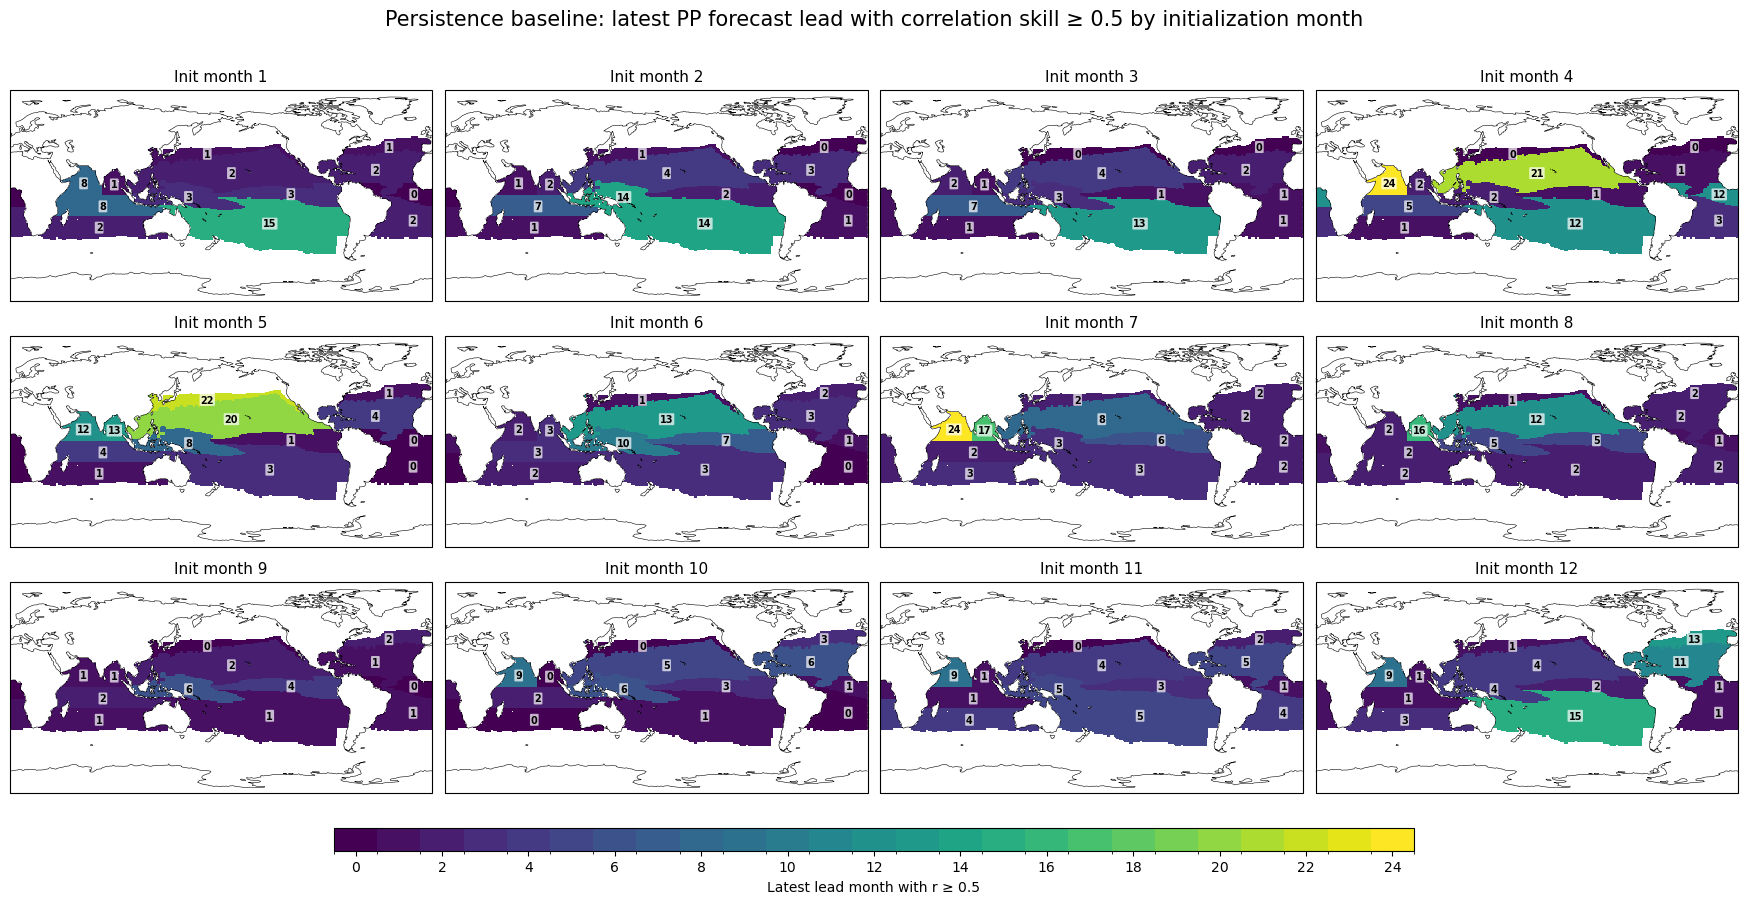

In [3]:
latest_by_month = ds_pers["latest_lead_corr_ge_05_persistence_by_init_month"]

fig, axes = plt.subplots(
    3, 4,
    figsize=(18, 9),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)}
)

axes = axes.ravel()

bounds = np.arange(-0.5, MAX_LEAD + 1.5, 1)
cmap = plt.get_cmap("viridis", MAX_LEAD + 1).copy()
cmap.set_bad((1, 1, 1, 0))
norm = BoundaryNorm(bounds, cmap.N)

for imonth, ax in enumerate(axes, start=1):
    vals = latest_by_month.sel(init_month=imonth)

    lead_map_m = xr.full_like(mask, fill_value=np.nan, dtype=np.float32)

    for reg in vals["region"].values:
        lead_map_m = lead_map_m.where(
            mask != int(reg),
            float(vals.sel(region=reg).values),
        )

    im = ax.pcolormesh(
        lon,
        lat,
        lead_map_m.where(mask > 0),
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    if "seamask" in ds_mask:
        ax.contour(
            lon,
            lat,
            ds_mask["seamask"],
            levels=[0.5],
            colors="k",
            linewidths=0.25,
            transform=ccrs.PlateCarree(),
        )
    else:
        ax.coastlines(linewidth=0.4)

    ax.set_global()
    ax.set_title(f"Init month {imonth}", fontsize=11)

    # Only latest lead value
    for reg in vals["region"].values:
        region_mask = mask.values == int(reg)
        lon_c, lat_c = weighted_centroid(lon, lat, region_mask)

        if np.isfinite(lon_c) and np.isfinite(lat_c):
            val = int(vals.sel(region=reg).values)

            ax.text(
                lon_to_180(lon_c),
                lat_c,
                str(val),
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=7,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.7,
                    boxstyle="round,pad=0.10",
                ),
            )

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.90,
    bottom=0.10,
    wspace=0.03,
    hspace=0.08,
)

cax = fig.add_axes([0.20, 0.045, 0.60, 0.025])
cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(0, MAX_LEAD + 1, 2),
)
cbar.set_label("Latest lead month with r ≥ 0.5")

fig.suptitle(
    "Persistence baseline: latest PP forecast lead with correlation skill ≥ 0.5 by initialization month",
    fontsize=15,
)

plt.show()